In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import os

import clickhouse_connect

# Show all rows
pd.set_option("display.max_rows", None)

# Show all columns
pd.set_option("display.max_columns", None)

# Make sure wide DataFrames don't wrap
pd.set_option("display.width", None)

# Show the full content of each column (no '...')
pd.set_option("display.max_colwidth", None)

In [2]:
client = clickhouse_connect.get_client(
    host='yaujulxk39.eastus2.azure.clickhouse.cloud',      # or server IP
    port=8443,             # HTTP port (default)
    username='default',
    password='~gZjRLjjOJh1i',
    database='Competitive_Analysis'
)

In [3]:
# ---- Query ----
df_hum_hist = client.query_df("""
    SELECT *
    FROM Competitive_Analysis.DRGHistoricalReviewInformation
    WHERE Client = 'Hum'
""")
df_hum_hist.shape

(76355, 291)

In [4]:
# -------------------------------------------------
# Initial shape of the dataset
# -------------------------------------------------
df_hum = df_hum_hist.copy()

print(df_hum.shape)  

df_hum = df_hum[df_hum['InitialDenialType'] == 'Substantive']
print(df_hum.shape) 

# -------------------------------------------------
# Identify valid Group_Type values
# -------------------------------------------------

group_type_unique = df_hum['Group_Type'].dropna().unique()
print(group_type_unique) 

# -------------------------------------------------
# Filter dataset to only valid Group_Type rows
# Use .copy() to avoid SettingWithCopyWarning
# -------------------------------------------------
df_hum_group_type = df_hum[df_hum['Group_Type'].isin(group_type_unique)].copy()
print(df_hum_group_type.shape) 

# -------------------------------------------------
# Calculate ADRG length
# -------------------------------------------------
df_hum_group_type.loc[:, 'len_adrg'] = (
    df_hum_group_type['ADRG'].astype(str).str.len()
)

print(df_hum_group_type['len_adrg'].value_counts())
print(df_hum_group_type['Group_Type'].value_counts())

# -------------------------------------------------
# Remove invalid DRG / Group_Type combinations
#   1) Group_Type = '01' and ADRG length = 4
#   2) Group_Type = '10' and ADRG length = 3
# -------------------------------------------------
mask_remove = (
    ((df_hum_group_type['Group_Type'] == '01') & (df_hum_group_type['len_adrg'] == 4)) |
    ((df_hum_group_type['Group_Type'] == '10') & (df_hum_group_type['len_adrg'] == 3))
)

df_hum_drg_rem = df_hum_group_type.loc[~mask_remove].copy()
print(df_hum_drg_rem.shape)

# -------------------------------------------------
# Create a copy of InitialDeterminationDate
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = (
    df_hum_drg_rem['InitialDeterminationDate']
)

print(
    df_hum_drg_rem['Control_ID']
    .value_counts()
    .sort_values(ascending=False)
    .head()
)

# -------------------------------------------------
# Convert date column to datetime
# -------------------------------------------------
df_hum_drg_rem.loc[:, 'InitialDeterminationDate_copy'] = pd.to_datetime(
    df_hum_drg_rem['InitialDeterminationDate_copy'],
    errors='coerce'
)

# -------------------------------------------------
# Keep latest record per Control_ID
# -------------------------------------------------
df_sorted = df_hum_drg_rem.sort_values(
    'InitialDeterminationDate_copy',
    ascending=False
)

df_hum_latest = df_sorted.drop_duplicates(
    subset='Control_ID',
    keep='first'
).copy()

print(df_hum_latest.shape)

# -------------------------------------------------
# Normalize string columns
# -------------------------------------------------
df_hum_latest.loc[:, 'ADRG'] = (
    df_hum_latest['ADRG'].astype(str).str.strip()
)

df_hum_latest.loc[:, 'PRIM_DX'] = (
    df_hum_latest['PRIM_DX'].astype(str).str.strip().str.upper()
)

df_hum_latest.loc[:, 'InitialDeterminationStatus'] = (
    df_hum_latest['InitialDeterminationStatus']
    .astype(str)
    .str.strip()
    .str.upper()
)

# -------------------------------------------------
# Clean numeric fields
# -------------------------------------------------
df_hum_latest.loc[:, 'IDSavings'] = (
    pd.to_numeric(df_hum_latest['IDSavings'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'LOS'] = (
    pd.to_numeric(df_hum_latest['LOS'], errors='coerce').fillna(0)
)

df_hum_latest.loc[:, 'AGE'] = (
    pd.to_numeric(df_hum_latest['AGE'], errors='coerce')
)

# -------------------------------------------------
# Validate AGE values
# -------------------------------------------------
max_age = df_hum_latest['AGE'].max()

df_hum_latest = df_hum_latest[(
    df_hum_latest['AGE'].between(0, max_age))
].copy()
df_hum_latest.loc[:, 'AGE'] = df_hum_latest['AGE'].astype('Int64')
print(df_hum_latest.shape)

# -------------------------------------------------
# Validate LOS values
# -------------------------------------------------
df_hum_latest.loc[:, 'LOS'] = (
    df_hum_latest['LOS'].astype('Int64')
)

df_hum_latest = df_hum_latest[(df_hum_latest['LOS'] >= 0)].copy()
print(df_hum_latest.shape)

# -------------------------------------------------
# Remove extreme savings outliers
# -------------------------------------------------
df_hum_latest = df_hum_latest[
    df_hum_latest['IDSavings'] < 650000
].reset_index(drop=True)

print(df_hum_latest.shape)

# Date only
df_hum_latest['InitialDeterminationDate_date'] = (
    df_hum_latest['InitialDeterminationDate'].dt.date
)

# Year
df_hum_latest['InitialDetermination_Year'] = (
    df_hum_latest['InitialDeterminationDate'].dt.year
)

df_hum_latest["InitialDeterminationDate_date"] = pd.to_datetime(
    df_hum_latest["InitialDeterminationDate_date"],
    errors="coerce"   # handles bad / empty values safely
)


df_hum_latest['Target'] = (
    df_hum_latest['InitialDeterminationStatus']
    .str.strip()
    .str.upper()
    .map({
        'APPROVED': 0,
        'DENIED': 1
    })
)


df_hum_latest.shape

(76355, 291)
(76355, 291)
<StringArray>
['01', '10']
Length: 2, dtype: string
(76351, 291)
len_adrg
3    75215
4     1136
Name: count, dtype: int64
Group_Type
01    75214
10     1137
Name: count, dtype: Int64
(76340, 292)
Control_ID
HUPTMR-40741    1
HUPTMR-9633     1
HUPTMR-51303    1
HUPTMR-9989     1
HUPTMR-10906    1
Name: count, dtype: Int64
(76340, 293)
(76339, 293)
(76337, 293)
(76337, 293)


(76337, 296)

In [5]:
df_hum_ms_drg = df_hum_latest[df_hum_latest['Group_Type']=='01']
print(df_hum_ms_drg.shape)

df_hum_ms_drg['len_adrg'].value_counts()

(75206, 296)


len_adrg
3    75206
Name: count, dtype: int64

In [6]:
# ============================================================
# 🔥 CLAIM DENIAL PIPELINE - B-PART REMOVED (PRODUCTION READY)
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768
QUERY = torch.randn(EMB_DIM, device=DEVICE)

# ============================================================
# 1. LOAD DATA
# ============================================================
df = df_hum_ms_drg.copy()
df = df.rename(columns={'AGE':'Age'})

# ============================================================
# 2. CREATE DX / PX LISTS
# ============================================================
adx_cols = [f"A_DX{i}" for i in range(2,26)]
apx_cols = [f"A_PX{i}" for i in range(1,26)]
df["A_DX_List"] = df[adx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["A_PX_List"] = df[apx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

# ============================================================
# 3. SPLIT DX TYPES
# ============================================================
def split_dx_types(dx_string):
    if pd.isna(dx_string) or dx_string=="": 
        return pd.Series(["","","",0,0,0])
    dx_list = [x.strip() for x in dx_string.split(",")]
    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc  = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    gen = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]
    return pd.Series([",".join(sorted(mcc)),",".join(sorted(cc)),",".join(sorted(gen)),
                      len(mcc),len(cc),len(gen)])

df[["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
    "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]] = df["A_DX_List"].apply(split_dx_types)

# ============================================================
# 4. LOAD EMBEDDINGS
# ============================================================
with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    data = pickle.load(f)

drg_dict, icd_dict, proc_dict = data["drg_dict"], data["icd_dict"], data["proc_dict"]

def get_single_emb(code, emb_dict):
    if pd.isna(code): return np.zeros(EMB_DIM, dtype=np.float32)
    emb = emb_dict.get(str(code).strip())
    if emb is None or len(emb)!=EMB_DIM: return np.zeros(EMB_DIM, dtype=np.float32)
    return np.array(emb, dtype=np.float32)

df["DRG_EMB"] = df["ADRG"].apply(lambda x: get_single_emb(x, drg_dict))
df["PRIM_DX_EMB"] = df["PRIM_DX"].apply(lambda x: get_single_emb(x, icd_dict))

def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(icd_dict[c.strip()],dtype=np.float32) for c in codes 
            if c.strip() in icd_dict and len(icd_dict[c.strip()])==EMB_DIM]

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(proc_dict[c.strip()],dtype=np.float32) for c in codes 
            if c.strip() in proc_dict and len(proc_dict[c.strip()])==EMB_DIM]

df["MCC_EMB_LIST"] = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
df["CC_EMB_LIST"] = df["A_DX_CC_Set"].apply(map_icd_embeddings)
df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)
df["PROC_EMB_LIST"] = df["A_PX_List"].apply(map_proc_embeddings)

df = df[~df["DRG_EMB"].isnull()]

# ============================================================
# 5. ATTENTION POOLING
# ============================================================
def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []
    for lst in col:
        if not isinstance(lst, list) or len(lst)==0:
            pooled.append(zero_vec)
            continue
        lst = [x for x in lst if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)]
        if len(lst)==0: pooled.append(zero_vec); continue
        if len(lst)==1: pooled.append(lst[0]); continue
        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()
        pooled.append(vec.astype(np.float32) if vec.shape==(EMB_DIM,) else zero_vec)
    return pd.Series(pooled, index=col.index)

df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
df["CC_EMB_POOLED"] = attention_pooling(df["CC_EMB_LIST"])
df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])

# ============================================================
# 6. TRAIN / VALID SPLIT
# ============================================================
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Target"])

# ============================================================
# 7. SCALING
# ============================================================
num_cols = ["Payments","LOS","Age"]
scaler = StandardScaler()
train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
valid_df.loc[:,num_cols] = scaler.transform(valid_df[num_cols])

# ============================================================
# 8. TARGET ENCODING
# ============================================================
def target_encode(train, valid, col, alpha=20):
    mean = train["Target"].mean()
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    smooth = (stats["mean"]*stats["count"] + mean*alpha)/(stats["count"]+alpha)
    train[col+"_enc"] = train[col].map(smooth)
    valid[col+"_enc"] = valid[col].map(smooth)
    valid[col+"_enc"] = valid[col+"_enc"].fillna(mean)
    return train, valid

train_df, valid_df = target_encode(train_df, valid_df, "ADRG")
train_df, valid_df = target_encode(train_df, valid_df, "PRIM_DX")

# ============================================================
# 9. CREATE STATS FEATURES
# ============================================================
def create_stats(train, col):
    temp = train[[col,"Target"]].dropna()
    temp[col] = temp[col].str.split(",")
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()
    stats = temp.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

def apply_stats(df, stats, col, prefix):
    def calc(x):
        if pd.isna(x): return [0,0]
        vals = [stats.loc[c.strip()] for c in str(x).split(",") if c.strip() in stats.index]
        if not vals: return [0,0]
        rates = [v["rate"] for v in vals]
        freqs = [v["freq"] for v in vals]
        return [np.mean(rates), np.mean(freqs)]
    tmp = df[col].apply(calc)
    df[prefix+"_rate"] = tmp.apply(lambda x: x[0])
    df[prefix+"_freq"] = tmp.apply(lambda x: x[1])
    return df

cols = ["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_PX_List"]
prefix = ["MCC","CC","GEN","PX"]
stats_store = {}
for c in cols:
    stats_store[c] = create_stats(train_df, c)
for c,p in zip(cols,prefix):
    train_df = apply_stats(train_df, stats_store[c], c, p)
    valid_df = apply_stats(valid_df, stats_store[c], c, p)

# ============================================================
# 10. BUILD FEATURES
# ============================================================
def safe_stack(series):
    return np.stack(series.apply(lambda x: x if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,) 
                                 else np.zeros(EMB_DIM,dtype=np.float32)))

def build_X(df):
    drg = safe_stack(df["DRG_EMB"])
    pdx = safe_stack(df["PRIM_DX_EMB"])
    mcc = safe_stack(df["MCC_EMB_POOLED"])
    cc  = safe_stack(df["CC_EMB_POOLED"])
    gen = safe_stack(df["GENERAL_EMB_POOLED"])
    proc = safe_stack(df["PROC_EMB_POOLED"])
    emb = np.concatenate([drg,pdx,mcc,cc,gen,proc], axis=1)
    counts = df[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values
    numeric = df[["Payments","LOS","Age"]].values
    stats = df[["ADRG_enc","PRIM_DX_enc","MCC_rate","MCC_freq","CC_rate","CC_freq",
                "GEN_rate","GEN_freq","PX_rate","PX_freq"]].values
    return np.concatenate([emb, counts, numeric, stats], axis=1)

X_train = build_X(train_df)
X_valid = build_X(valid_df)
y_train = train_df["Target"].values
y_valid = valid_df["Target"].values



C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28832\218270067.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.75075851  1.01696205 -0.10795103 ... -0.42935477 -0.91146038
  0.85626018]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28832\218270067.py:122: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.14788316 -0.06461541  0.43499111 ...  1.43420414 -0.89729294
 -0.48095417]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28832\218270067.py:123: FutureWarning: Setting an item of incompatible dtype is deprecate

In [ ]:
# ============================================================
# 11. TRAIN LIGHTGBM
# ============================================================
model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.021269,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.95458,
    colsample_bytree=0.6615,
    reg_alpha=1.3065,
    reg_lambda=4.5798,
    scale_pos_weight=4.8305
)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.428257
y_pred = (y_pred_prob>=THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

In [7]:
import optuna
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.metrics import recall_score, precision_score, confusion_matrix

# ============================================================
# 🔥 OBJECTIVE FUNCTION (UPDATED)
# ============================================================

def objective(trial):

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 300, 800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.05),
        "num_leaves": trial.suggest_int("num_leaves", 20, 70),
        "max_depth": trial.suggest_int("max_depth", 4, 8),
        "min_child_samples": trial.suggest_int("min_child_samples", 40, 120),

        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 0.9),

        "reg_alpha": trial.suggest_float("reg_alpha", 0.5, 3.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1.0, 5.0),

        # 🔥 Reduced range to avoid FP explosion
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 1.0, 3.0),

        "random_state": 42,
        "n_jobs": -1
    }

    model = LGBMClassifier(**params)
    model.fit(X_train, y_train)

    probs = model.predict_proba(X_valid)[:, 1]

    # 🔥 Safer threshold range
    threshold = trial.suggest_float("threshold", 0.5, 0.7)
    preds = (probs > threshold).astype(int)

    # Metrics
    recall = recall_score(y_valid, preds)
    precision = precision_score(y_valid, preds)

    tn, fp, fn, tp = confusion_matrix(y_valid, preds).ravel()
    fp_rate = fp / (fp + tn)

    # 🚨 Hard constraint: avoid useless models
    if precision < 0.45:
        return 0

    # 🔥 Balanced objective (key change)
    score = (0.6 * recall) + (0.4 * precision) - (0.8 * fp_rate)

    return score


# ============================================================
# 🚀 RUN OPTUNA
# ============================================================

study = optuna.create_study(direction="maximize")

study.optimize(objective, n_trials=100)   # increase to 150+ if time allows


# ============================================================
# 🏆 BEST PARAMS
# ============================================================

print("Best Score:", study.best_value)
print("Best Params:", study.best_params)


# ============================================================
# 🔥 TRAIN FINAL MODEL
# ============================================================

best_params = study.best_params.copy()
best_threshold = best_params.pop("threshold")

final_model = LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)


# ============================================================
# 📊 FINAL EVALUATION
# ============================================================

from sklearn.metrics import classification_report, roc_auc_score

probs = final_model.predict_proba(X_valid)[:, 1]
preds = (probs > best_threshold).astype(int)

print("\nFinal Threshold:", best_threshold)
print(confusion_matrix(y_valid, preds))
print(classification_report(y_valid, preds))
print("ROC-AUC:", roc_auc_score(y_valid, probs))

[I 2026-03-30 19:28:35,728] A new study created in memory with name: no-name-6a019bed-1cda-4c40-a56d-0b4a93e251a2


[LightGBM] [Info] Number of positive: 7209, number of negative: 52955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.660442 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151673
[LightGBM] [Info] Number of data points in the train set: 60164, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119822 -> initscore=-1.994112
[LightGBM] [Info] Start training from score -1.994112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-03-30 19:29:04,217] Trial 0 finished with value: 0.3941259627604106 and parameters: {'n_estimators': 386, 'learning_rate': 0.022007215499567124, 'num_leaves': 54, 'max_depth': 5, 'min_child_samples': 86, 'subsample': 0.8827727486629996, 'colsample_bytree': 0.7083792970986729, 'reg_alpha': 1.1977712156968527, 'reg_lambda': 1.1877229660320836, 'scale_pos_weight': 1.338139180890362, 'threshold': 0.5766234958530969}. Best is trial 0 with value: 0.3941259627604106.


[LightGBM] [Info] Number of positive: 7209, number of negative: 52955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.638950 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151673
[LightGBM] [Info] Number of data points in the train set: 60164, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119822 -> initscore=-1.994112
[LightGBM] [Info] Start training from score -1.994112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-03-30 19:29:30,695] Trial 1 finished with value: 0.38844395838744517 and parameters: {'n_estimators': 377, 'learning_rate': 0.033693830645486915, 'num_leaves': 29, 'max_depth': 4, 'min_child_samples': 120, 'subsample': 0.9860151590020372, 'colsample_bytree': 0.6265382807360231, 'reg_alpha': 1.11146064165359, 'reg_lambda': 3.4811235491477515, 'scale_pos_weight': 1.926986486046298, 'threshold': 0.6651204116276971}. Best is trial 0 with value: 0.3941259627604106.


...

[LightGBM] [Info] Number of positive: 7209, number of negative: 52955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.695983 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151673
[LightGBM] [Info] Number of data points in the train set: 60164, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119822 -> initscore=-1.994112
[LightGBM] [Info] Start training from score -1.994112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-03-30 21:49:38,072] Trial 99 finished with value: 0.44103813323674856 and parameters: {'n_estimators': 364, 'learning_rate': 0.011085225819189075, 'num_leaves': 56, 'max_depth': 6, 'min_child_samples': 44, 'subsample': 0.9577453323955094, 'colsample_bytree': 0.7215449757187664, 'reg_alpha': 2.89282212521134, 'reg_lambda': 2.7997672668909304, 'scale_pos_weight': 2.9157304554178616, 'threshold': 0.5337036329722236}. Best is trial 84 with value: 0.4441651434320568.
c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT

Best Score: 0.4441651434320568
Best Params: {'n_estimators': 365, 'learning_rate': 0.011260285162166248, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.9709137025948372, 'colsample_bytree': 0.7569914852174505, 'reg_alpha': 2.9586240242195894, 'reg_lambda': 2.7612655738921585, 'scale_pos_weight': 2.9700896293454764, 'threshold': 0.5189319811483234}
[LightGBM] [Info] Number of positive: 7209, number of negative: 52955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.704097 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151673
[LightGBM] [Info] Number of data points in the train set: 60164, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119822 -> initscore=-1.994112
[LightGBM] [Info] Start training from score -1.994112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positi

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



Final Threshold: 0.5189319811483234
[[12521   719]
 [  986   816]]
              precision    recall  f1-score   support

           0       0.93      0.95      0.94     13240
           1       0.53      0.45      0.49      1802

    accuracy                           0.89     15042
   macro avg       0.73      0.70      0.71     15042
weighted avg       0.88      0.89      0.88     15042

ROC-AUC: 0.8430197145836618


In [ ]:
print("Best Score:", study.best_value)
print("Best Params:", study.best_params)

#Best Score: 0.4441651434320568
#Best Params: {'n_estimators': 365, 'learning_rate': 0.011260285162166248, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.9709137025948372, 'colsample_bytree': 0.7569914852174505, 'reg_alpha': 2.9586240242195894, 'reg_lambda': 2.7612655738921585, 'scale_pos_weight': 2.9700896293454764, 'threshold': 0.5189319811483234}

Best Score: 0.4441651434320568
Best Params: {'n_estimators': 365, 'learning_rate': 0.011260285162166248, 'num_leaves': 54, 'max_depth': 6, 'min_child_samples': 40, 'subsample': 0.9709137025948372, 'colsample_bytree': 0.7569914852174505, 'reg_alpha': 2.9586240242195894, 'reg_lambda': 2.7612655738921585, 'scale_pos_weight': 2.9700896293454764, 'threshold': 0.5189319811483234}


In [ ]:
best_params = study.best_params.copy()

# Remove threshold (not part of model)
best_threshold = best_params.pop("threshold")

final_model = LGBMClassifier(**best_params)
final_model.fit(X_train, y_train)

# Final predictions
probs = final_model.predict_proba(X_valid)[:,1]
preds = (probs > best_threshold).astype(int)

[LightGBM] [Info] Number of positive: 7209, number of negative: 52955
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.830753 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1151601
[LightGBM] [Info] Number of data points in the train set: 60164, number of used features: 4624
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.119822 -> initscore=-1.994112
[LightGBM] [Info] Start training from score -1.994112
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


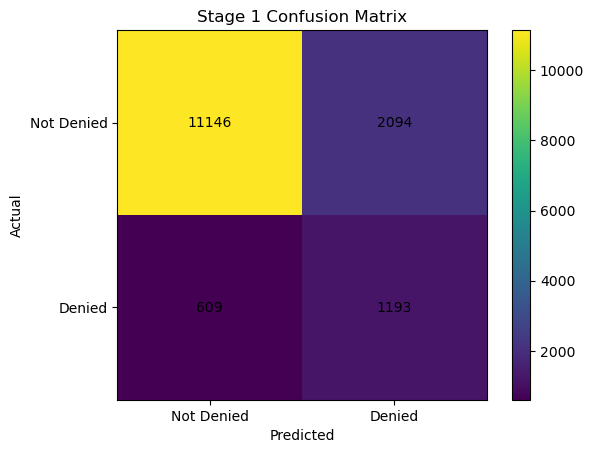

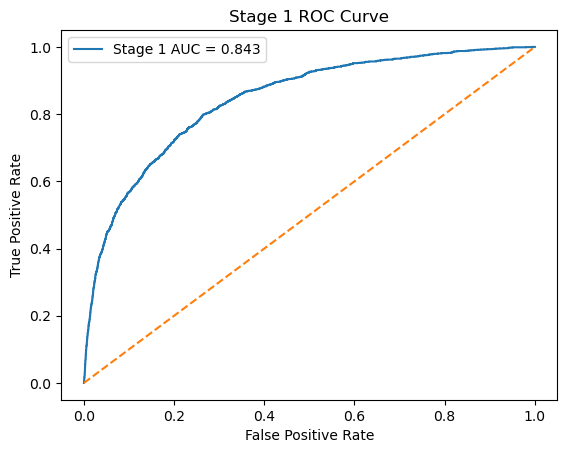

[LightGBM] [Info] Number of positive: 1193, number of negative: 2094
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.205498 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1004753
[LightGBM] [Info] Number of data points in the train set: 3287, number of used features: 4625
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.362945 -> initscore=-0.562605
[LightGBM] [Info] Start training from score -0.562605
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


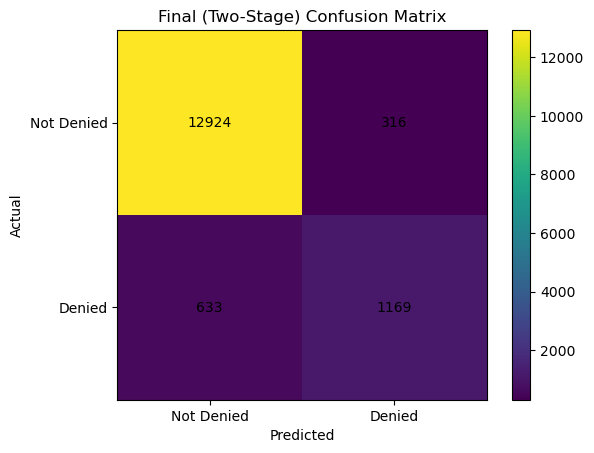

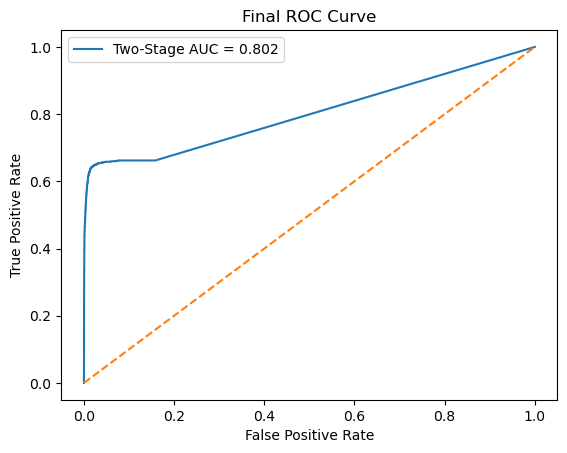

Stage 1 Passed Cases: 3287

FINAL RESULTS:
[[12924   316]
 [  633  1169]]
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     13240
           1       0.79      0.65      0.71      1802

    accuracy                           0.94     15042
   macro avg       0.87      0.81      0.84     15042
weighted avg       0.93      0.94      0.93     15042

ROC-AUC: 0.8023223608545055


In [18]:
# ============================================================
# 🔥 FULL TWO-STAGE PIPELINE + VISUALIZATION (SINGLE CELL)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ============================================================
# 🔥 STAGE 1 MODEL (OPTUNA PARAMS - HIGH RECALL)
# ============================================================

stage1_model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.02126904140506236,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.9545822444135974,
    colsample_bytree=0.6615288127260239,
    reg_alpha=1.306597950617057,
    reg_lambda=4.579866204146278,
    scale_pos_weight=4.8305186183209345,
    random_state=42,
    n_jobs=-1
)

stage1_model.fit(X_train, y_train)

# Stage 1 predictions
probs_stage1 = stage1_model.predict_proba(X_valid)[:, 1]
stage1_threshold = 0.4282574824046108
stage1_preds = (probs_stage1 > stage1_threshold).astype(int)
stage1_mask = stage1_preds.astype(bool)

# ============================================================
# 📊 STAGE 1 CONFUSION MATRIX
# ============================================================

cm1 = confusion_matrix(y_valid, stage1_preds)

plt.figure()
plt.imshow(cm1)
plt.title("Stage 1 Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])

for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, cm1[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 STAGE 1 ROC CURVE
# ============================================================

fpr1, tpr1, _ = roc_curve(y_valid, probs_stage1)
auc1 = roc_auc_score(y_valid, probs_stage1)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Stage 1 AUC = {auc1:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 1 ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 🔥 PREPARE STAGE 2 DATA
# ============================================================

X_stage2 = X_valid[stage1_mask].copy()
y_stage2 = y_valid[stage1_mask]

X_stage2 = np.hstack([
    X_stage2,
    probs_stage1[stage1_mask].reshape(-1,1)
])

# ============================================================
# 🔥 STAGE 2 MODEL (BALANCED OPTUNA PARAMS)
# ============================================================

stage2_model = LGBMClassifier(
    n_estimators=348,
    learning_rate=0.018321074923569082,
    num_leaves=32,
    max_depth=6,
    min_child_samples=91,
    subsample=0.976533671330113,
    colsample_bytree=0.6861578285305313,
    reg_alpha=1.2161768866427825,
    reg_lambda=3.698341838082158,
    scale_pos_weight=2.9316719462212024,
    random_state=42,
    n_jobs=-1
)

stage2_model.fit(X_stage2, y_stage2)

# ============================================================
# 🔥 FINAL PREDICTIONS (TWO-STAGE)
# ============================================================

final_preds = np.zeros(len(X_valid))
final_probs = np.zeros(len(X_valid))

X_stage2_full = X_valid[stage1_mask].copy()
X_stage2_full = np.hstack([
    X_stage2_full,
    probs_stage1[stage1_mask].reshape(-1,1)
])

probs_stage2 = stage2_model.predict_proba(X_stage2_full)[:, 1]

stage2_threshold = 0.5058609937194245
stage2_preds = (probs_stage2 > stage2_threshold).astype(int)

final_preds[stage1_mask] = stage2_preds
final_probs[stage1_mask] = probs_stage2

# ============================================================
# 📊 FINAL CONFUSION MATRIX
# ============================================================

cm2 = confusion_matrix(y_valid, final_preds)

plt.figure()
plt.imshow(cm2)
plt.title("Final (Two-Stage) Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])

for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 FINAL ROC CURVE
# ============================================================

fpr2, tpr2, _ = roc_curve(y_valid, final_probs)
auc2 = roc_auc_score(y_valid, final_probs)

plt.figure()
plt.plot(fpr2, tpr2, label=f"Two-Stage AUC = {auc2:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 📊 FINAL METRICS
# ============================================================

print("Stage 1 Passed Cases:", stage1_mask.sum())

print("\nFINAL RESULTS:")
print(confusion_matrix(y_valid, final_preds))
print(classification_report(y_valid, final_preds))
print("ROC-AUC:", auc2)

# prev

In [15]:
# ============================================================
# 🔥 FULL CLAIM DENIAL PIPELINE - OPTIMIZED WITH PCA
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768
QUERY = torch.randn(EMB_DIM, device=DEVICE)

# ============================================================
# 1. LOAD DATA
# ============================================================
df = df_hum_ms_drg.copy()
df = df.rename(columns={'AGE':'Age'})

# ============================================================
# 2. CREATE DX / PX LISTS
# ============================================================
adx_cols = [f"A_DX{i}" for i in range(2,26)]
apx_cols = [f"A_PX{i}" for i in range(1,26)]
df["A_DX_List"] = df[adx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["A_PX_List"] = df[apx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

adx_cols_b = [f"B_DX{i}" for i in range(2,26)]
apx_cols_b = [f"B_PX{i}" for i in range(1,26)]
df["B_DX_List"] = df[adx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["B_PX_List"] = df[apx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

# ============================================================
# 3. SPLIT DX TYPES
# ============================================================
def split_dx_types(dx_string):
    if pd.isna(dx_string) or dx_string=="":
        return pd.Series(["","","",0,0,0])
    dx_list = [x.strip() for x in dx_string.split(",")]
    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc  = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    gen = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]
    return pd.Series([",".join(sorted(mcc)),",".join(sorted(cc)),",".join(sorted(gen)),len(mcc),len(cc),len(gen)])

# A-side
df[[
    "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
    "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"
]] = df["A_DX_List"].apply(split_dx_types)

# B-side
df[[
    "B_DX_MCC_Set","B_DX_CC_Set","B_DX_General_Set",
    "B_DX_MCC_Count","B_DX_CC_Count","B_DX_General_Count"
]] = df["B_DX_List"].apply(split_dx_types)

# ============================================================
# 4. CLEAN DATA
# ============================================================
df = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
df = df[~(df['B_DX_List'].notna() & (df['B_DX_List'].str.len() == 0))]
df = df.dropna(subset=['B_DRG','B_PRIMDX'])

# ============================================================
# 5. B-PART FLAGS
# ============================================================
df["B_PRIMDX_CLEAN"] = df["B_PRIMDX"].str.replace(r"\s*-\s*(MCC|CC)","",regex=True).str.strip().str.upper()

def get_pdx_flag(row):
    a_prim = str(row["PRIM_DX"]).strip()
    b_prim = str(row["B_PRIMDX_CLEAN"]).strip()
    A_set = set(filter(None,[row["A_DX_MCC_Set"],row["A_DX_CC_Set"],row["A_DX_General_Set"]]))
    B_set = set(filter(None,[row["B_DX_MCC_Set"],row["B_DX_CC_Set"],row["B_DX_General_Set"]]))
    if a_prim==b_prim: return "SAME"
    if (b_prim in A_set) and (a_prim in B_set): return "RESEQUENCE"
    if a_prim not in B_set:
        if b_prim in A_set: return "PDX_DOWNGRADE"
        else: return "A_PRIMDX_REMOVED"
    return "B_PDX_Added"

df["PDX_FLAG"] = df.apply(get_pdx_flag,axis=1)

def check_px_removed(row):
    A_set = set(filter(None, row["A_PX_List"].split(",")))
    B_set = set(filter(None, row["B_PX_List"].split(",")))
    if A_set == B_set: return pd.Series(["SAME",""])
    removed = A_set - B_set
    return pd.Series(["REMOVED", ",".join(sorted(removed)) if removed else ""])

df[["PX_FLAG","PX_REMOVED"]] = df.apply(check_px_removed,axis=1)
df["DRG_FLAG"] = np.where(df["ADRG"]==df["B_DRG"], "SAME","DIFFERENT")

# ============================================================
# 6. LOAD EMBEDDINGS
# ============================================================
with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    data = pickle.load(f)

drg_dict, icd_dict, proc_dict = data["drg_dict"], data["icd_dict"], data["proc_dict"]

def get_single_emb(code, emb_dict):
    if pd.isna(code):
        return np.zeros(EMB_DIM, dtype=np.float32)
    emb = emb_dict.get(str(code).strip())
    if emb is None or len(emb)!=EMB_DIM:
        return np.zeros(EMB_DIM, dtype=np.float32)
    return np.array(emb, dtype=np.float32)

df["DRG_EMB"] = df["ADRG"].apply(lambda x: get_single_emb(x, drg_dict))
df["PRIM_DX_EMB"] = df["PRIM_DX"].apply(lambda x: get_single_emb(x, icd_dict))

def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(icd_dict[c.strip()],dtype=np.float32) for c in codes if c.strip() in icd_dict and len(icd_dict[c.strip()])==EMB_DIM]

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(proc_dict[c.strip()],dtype=np.float32) for c in codes if c.strip() in proc_dict and len(proc_dict[c.strip()])==EMB_DIM]

df["MCC_EMB_LIST"] = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
df["CC_EMB_LIST"] = df["A_DX_CC_Set"].apply(map_icd_embeddings)
df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)
df["PROC_EMB_LIST"] = df["A_PX_List"].apply(map_proc_embeddings)

df = df[~df["DRG_EMB"].isnull()]

# ============================================================
# 7. ATTENTION POOLING PER TYPE
# ============================================================
def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []
    for lst in col:
        if not isinstance(lst, list) or len(lst)==0:
            pooled.append(zero_vec)
            continue
        lst = [x for x in lst if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)]
        if len(lst)==0:
            pooled.append(zero_vec)
            continue
        if len(lst)==1:
            pooled.append(lst[0])
            continue
        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()
        pooled.append(vec.astype(np.float32) if vec.shape==(EMB_DIM,) else zero_vec)
    return pd.Series(pooled, index=col.index)

df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
df["CC_EMB_POOLED"] = attention_pooling(df["CC_EMB_LIST"])
df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])

# ============================================================
# 8. REDUCE EMBEDDING DIM WITH PCA
# ============================================================
def reduce_emb(df_train, df_valid, col, n_components=128):
    X_train = np.stack(df_train[col].values)
    X_valid = np.stack(df_valid[col].values)
    pca = PCA(n_components=n_components)
    X_train_red = pca.fit_transform(X_train)
    X_valid_red = pca.transform(X_valid)
    return X_train_red, X_valid_red, pca

# ============================================================
# 9. TRAIN / VALID SPLIT
# ============================================================
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Target"])

# ============================================================
# 10. SCALING NUMERIC
# ============================================================
num_cols = ["Payments","LOS","Age"]
scaler = StandardScaler()
train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
valid_df.loc[:,num_cols] = scaler.transform(valid_df[num_cols])

# ============================================================
# 11. TARGET ENCODING
# ============================================================
def target_encode(train, valid, col, alpha=20):
    mean = train["Target"].mean()
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    smooth = (stats["mean"]*stats["count"] + mean*alpha)/(stats["count"]+alpha)
    train[col+"_enc"] = train[col].map(smooth)
    valid[col+"_enc"] = valid[col].map(smooth)
    valid[col+"_enc"] = valid[col+"_enc"].fillna(mean)
    return train, valid

train_df, valid_df = target_encode(train_df, valid_df, "ADRG")
train_df, valid_df = target_encode(train_df, valid_df, "PRIM_DX")

# ============================================================
# 12. CREATE STATS FEATURES
# ============================================================
def create_stats(train, col):
    temp = train[[col,"Target"]].dropna()
    temp[col] = temp[col].str.split(",")
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()
    stats = temp.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

def apply_stats(df, stats, col, prefix):
    def calc(x):
        if pd.isna(x):
            return [0,0]
        vals = [stats.loc[c.strip()] for c in str(x).split(",") if c.strip() in stats.index]
        if not vals:
            return [0,0]
        rates = [v["rate"] for v in vals]
        freqs = [v["freq"] for v in vals]
        return [np.mean(rates), np.mean(freqs)]
    tmp = df[col].apply(calc)
    df[prefix+"_rate"] = tmp.apply(lambda x: x[0])
    df[prefix+"_freq"] = tmp.apply(lambda x: x[1])
    return df

cols = ["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_PX_List"]
prefix = ["MCC","CC","GEN","PX"]
stats_store = {}
for c in cols:
    stats_store[c] = create_stats(train_df, c)
for c,p in zip(cols,prefix):
    train_df = apply_stats(train_df, stats_store[c], c, p)
    valid_df = apply_stats(valid_df, stats_store[c], c, p)

# ============================================================
# 13. B-PART FLAG STATS
# ============================================================
def create_flag_stats(train, col):
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = [f"{col}_rate", f"{col}_freq"]
    return stats

def apply_flag(df, stats, col):
    mean = df["Target"].mean()
    df[f"{col}_rate"] = df[col].map(stats[f"{col}_rate"])
    df[f"{col}_freq"] = df[col].map(stats[f"{col}_freq"])
    df[f"{col}_rate"] = df[f"{col}_rate"].fillna(mean)
    df[f"{col}_freq"] = df[f"{col}_freq"].fillna(0)
    return df

for col in ["PDX_FLAG","PX_FLAG","DRG_FLAG"]:
    stats = create_flag_stats(train_df, col)
    train_df = apply_flag(train_df, stats, col)
    valid_df = apply_flag(valid_df, stats, col)

# ============================================================
# 14. BUILD FINAL FEATURES
# ============================================================
# Reduce embeddings with PCA per type
X_train_mcc, X_valid_mcc, pca_mcc = reduce_emb(train_df, valid_df, "MCC_EMB_POOLED", n_components=128)
X_train_cc, X_valid_cc, pca_cc = reduce_emb(train_df, valid_df, "CC_EMB_POOLED", n_components=128)
X_train_gen, X_valid_gen, pca_gen = reduce_emb(train_df, valid_df, "GENERAL_EMB_POOLED", n_components=64)
X_train_proc, X_valid_proc, pca_proc = reduce_emb(train_df, valid_df, "PROC_EMB_POOLED", n_components=128)
X_train_drg, X_valid_drg, pca_drg = reduce_emb(train_df, valid_df, "DRG_EMB", n_components=64)
X_train_pdx, X_valid_pdx, pca_pdx = reduce_emb(train_df, valid_df, "PRIM_DX_EMB", n_components=64)

# Combine all reduced embeddings
def build_X_final(df, X_drg, X_pdx, X_mcc, X_cc, X_gen, X_proc):
    counts = df[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values
    numeric = df[["Payments","LOS","Age"]].values
    stats = df[["ADRG_enc","PRIM_DX_enc","MCC_rate","MCC_freq","CC_rate","CC_freq"]].values
    bstats = df[["PDX_FLAG_rate","PDX_FLAG_freq","PX_FLAG_rate","PX_FLAG_freq","DRG_FLAG_rate","DRG_FLAG_freq"]].values
    return np.concatenate([X_drg,X_pdx,X_mcc,X_cc,X_gen,X_proc,counts,numeric,stats,bstats], axis=1)

X_train = build_X_final(train_df, X_train_drg,X_train_pdx,X_train_mcc,X_train_cc,X_train_gen,X_train_proc)
X_valid = build_X_final(valid_df, X_valid_drg,X_valid_pdx,X_valid_mcc,X_valid_cc,X_valid_gen,X_valid_proc)
y_train = train_df["Target"].values
y_valid = valid_df["Target"].values

print("Final feature shapes:", X_train.shape, X_valid.shape)

C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1162119462.py:187: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.74939739  0.37093225 -0.26925611 ... -0.26925611 -0.5893503
 -0.5893503 ]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1162119462.py:187: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.47972091 -0.2301876   1.7660789  ... -0.14700983 -0.81243199
  0.3520568 ]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1162119462.py:188: FutureWarning: Setting an item of incompatible dtype is depreca

Final feature shapes: (58534, 594) (14634, 594)


In [16]:

# ============================================================
# 14. TRAIN LIGHTGBM MODEL
# ============================================================
model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.021269,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.95458,
    colsample_bytree=0.6615,
    reg_alpha=1.3065,
    reg_lambda=4.5798,
    scale_pos_weight=4.8305
)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.428257
y_pred = (y_pred_prob>=THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))


[LightGBM] [Info] Number of positive: 7050, number of negative: 51484
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.186545 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 147162
[LightGBM] [Info] Number of data points in the train set: 58534, number of used features: 594
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120443 -> initscore=-1.988243
[LightGBM] [Info] Start training from score -1.988243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# prev

In [6]:
# ============================================================
# 🔥 FULL CLAIM DENIAL PIPELINE - UPDATED (PRODUCTION READY)
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768
QUERY = torch.randn(EMB_DIM, device=DEVICE)

# ============================================================
# 1. LOAD DATA
# ============================================================
df = df_hum_ms_drg.copy()
df = df.rename(columns={'AGE':'Age'})

# ============================================================
# 2. CREATE DX / PX LISTS
# ============================================================
adx_cols = [f"A_DX{i}" for i in range(2,26)]
apx_cols = [f"A_PX{i}" for i in range(1,26)]
df["A_DX_List"] = df[adx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["A_PX_List"] = df[apx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

adx_cols_b = [f"B_DX{i}" for i in range(2,26)]
apx_cols_b = [f"B_PX{i}" for i in range(1,26)]
df["B_DX_List"] = df[adx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["B_PX_List"] = df[apx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

# ============================================================
# 3. SPLIT DX TYPES
# ============================================================
def split_dx_types(dx_string):
    if pd.isna(dx_string) or dx_string=="":
        return pd.Series(["","","",0,0,0])
    dx_list = [x.strip() for x in dx_string.split(",")]
    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc  = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    gen = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]
    return pd.Series([",".join(sorted(mcc)),",".join(sorted(cc)),",".join(sorted(gen)),len(mcc),len(cc),len(gen)])

# A-side
df[[
    "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
    "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"
]] = df["A_DX_List"].apply(split_dx_types)

# B-side
df[[
    "B_DX_MCC_Set","B_DX_CC_Set","B_DX_General_Set",
    "B_DX_MCC_Count","B_DX_CC_Count","B_DX_General_Count"
]] = df["B_DX_List"].apply(split_dx_types)

# ============================================================
# 4. CLEAN DATA
# ============================================================
df = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
df = df[~(df['B_DX_List'].notna() & (df['B_DX_List'].str.len() == 0))]
df = df.dropna(subset=['B_DRG','B_PRIMDX'])

# ============================================================
# 5. B-PART FLAGS
# ============================================================
df["B_PRIMDX_CLEAN"] = df["B_PRIMDX"].str.replace(r"\s*-\s*(MCC|CC)","",regex=True).str.strip().str.upper()

def get_pdx_flag(row):
    a_prim = str(row["PRIM_DX"]).strip()
    b_prim = str(row["B_PRIMDX_CLEAN"]).strip()
    A_set = set(filter(None,[row["A_DX_MCC_Set"],row["A_DX_CC_Set"],row["A_DX_General_Set"]]))
    B_set = set(filter(None,[row["B_DX_MCC_Set"],row["B_DX_CC_Set"],row["B_DX_General_Set"]]))
    if a_prim==b_prim: return "SAME"
    if (b_prim in A_set) and (a_prim in B_set): return "RESEQUENCE"
    if a_prim not in B_set:
        if b_prim in A_set: return "PDX_DOWNGRADE"
        else: return "A_PRIMDX_REMOVED"
    return "B_PDX_Added"

df["PDX_FLAG"] = df.apply(get_pdx_flag,axis=1)

def check_px_removed(row):
    A_set = set(filter(None, row["A_PX_List"].split(",")))
    B_set = set(filter(None, row["B_PX_List"].split(",")))
    if A_set == B_set: return pd.Series(["SAME",""])
    removed = A_set - B_set
    return pd.Series(["REMOVED", ",".join(sorted(removed)) if removed else ""])

df[["PX_FLAG","PX_REMOVED"]] = df.apply(check_px_removed,axis=1)
df["DRG_FLAG"] = np.where(df["ADRG"]==df["B_DRG"], "SAME","DIFFERENT")

# ============================================================
# 6. LOAD EMBEDDINGS
# ============================================================
with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    data = pickle.load(f)

drg_dict, icd_dict, proc_dict = data["drg_dict"], data["icd_dict"], data["proc_dict"]

# ---------- SAFE SINGLE EMBEDDINGS ----------
def get_single_emb(code, emb_dict):
    if pd.isna(code):
        return np.zeros(EMB_DIM, dtype=np.float32)
    emb = emb_dict.get(str(code).strip())
    if emb is None or len(emb)!=EMB_DIM:
        return np.zeros(EMB_DIM, dtype=np.float32)
    return np.array(emb, dtype=np.float32)

df["DRG_EMB"] = df["ADRG"].apply(lambda x: get_single_emb(x, drg_dict))
df["PRIM_DX_EMB"] = df["PRIM_DX"].apply(lambda x: get_single_emb(x, icd_dict))

def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(icd_dict[c.strip()],dtype=np.float32) for c in codes if c.strip() in icd_dict and len(icd_dict[c.strip()])==EMB_DIM]

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str=="": return []
    codes = code_str.split(",")
    return [np.array(proc_dict[c.strip()],dtype=np.float32) for c in codes if c.strip() in proc_dict and len(proc_dict[c.strip()])==EMB_DIM]

df["MCC_EMB_LIST"] = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
df["CC_EMB_LIST"] = df["A_DX_CC_Set"].apply(map_icd_embeddings)
df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)
df["PROC_EMB_LIST"] = df["A_PX_List"].apply(map_proc_embeddings)

df = df[~df["DRG_EMB"].isnull()]

# ============================================================
# 7. ATTENTION POOLING (SAFE)
# ============================================================
def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []
    for lst in col:
        if not isinstance(lst, list) or len(lst)==0:
            pooled.append(zero_vec)
            continue
        lst = [x for x in lst if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)]
        if len(lst)==0:
            pooled.append(zero_vec)
            continue
        if len(lst)==1:
            pooled.append(lst[0])
            continue
        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()
        pooled.append(vec.astype(np.float32) if vec.shape==(EMB_DIM,) else zero_vec)
    return pd.Series(pooled, index=col.index)

df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
df["CC_EMB_POOLED"] = attention_pooling(df["CC_EMB_LIST"])
df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])

# ============================================================
# 8. TRAIN / VALID SPLIT
# ============================================================
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df["Target"])

# ============================================================
# 9. SCALING
# ============================================================
num_cols = ["Payments","LOS","Age"]
scaler = StandardScaler()
train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
valid_df.loc[:,num_cols] = scaler.transform(valid_df[num_cols])

# ============================================================
# 10. TARGET ENCODING
# ============================================================
def target_encode(train, valid, col, alpha=20):
    mean = train["Target"].mean()
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    smooth = (stats["mean"]*stats["count"] + mean*alpha)/(stats["count"]+alpha)
    train[col+"_enc"] = train[col].map(smooth)
    valid[col+"_enc"] = valid[col].map(smooth)
    valid[col+"_enc"] = valid[col+"_enc"].fillna(mean)
    return train, valid

train_df, valid_df = target_encode(train_df, valid_df, "ADRG")
train_df, valid_df = target_encode(train_df, valid_df, "PRIM_DX")

# ============================================================
# 11. CREATE STATS FEATURES
# ============================================================
def create_stats(train, col):
    temp = train[[col,"Target"]].dropna()
    temp[col] = temp[col].str.split(",")
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()
    stats = temp.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

def apply_stats(df, stats, col, prefix):
    def calc(x):
        if pd.isna(x):
            return [0,0]
        vals = [stats.loc[c.strip()] for c in str(x).split(",") if c.strip() in stats.index]
        if not vals:
            return [0,0]
        rates = [v["rate"] for v in vals]
        freqs = [v["freq"] for v in vals]
        return [np.mean(rates), np.mean(freqs)]
    tmp = df[col].apply(calc)
    df[prefix+"_rate"] = tmp.apply(lambda x: x[0])
    df[prefix+"_freq"] = tmp.apply(lambda x: x[1])
    return df

cols = ["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_PX_List"]
prefix = ["MCC","CC","GEN","PX"]
stats_store = {}
for c in cols:
    stats_store[c] = create_stats(train_df, c)
for c,p in zip(cols,prefix):
    train_df = apply_stats(train_df, stats_store[c], c, p)
    valid_df = apply_stats(valid_df, stats_store[c], c, p)

# ============================================================
# 12. B-PART FLAG STATS
# ============================================================
def create_flag_stats(train, col):
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = [f"{col}_rate", f"{col}_freq"]
    return stats

def apply_flag(df, stats, col):
    mean = df["Target"].mean()
    df[f"{col}_rate"] = df[col].map(stats[f"{col}_rate"])
    df[f"{col}_freq"] = df[col].map(stats[f"{col}_freq"])
    df[f"{col}_rate"] = df[f"{col}_rate"].fillna(mean)
    df[f"{col}_freq"] = df[f"{col}_freq"].fillna(0)
    return df

for col in ["PDX_FLAG","PX_FLAG","DRG_FLAG"]:
    stats = create_flag_stats(train_df, col)
    train_df = apply_flag(train_df, stats, col)
    valid_df = apply_flag(valid_df, stats, col)

# ============================================================
# 13. BUILD FEATURES
# ============================================================
def safe_stack(series):
    return np.stack(series.apply(lambda x: x if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,) else np.zeros(EMB_DIM,dtype=np.float32)))

def build_X(df):
    drg = safe_stack(df["DRG_EMB"])
    pdx = safe_stack(df["PRIM_DX_EMB"])
    mcc = safe_stack(df["MCC_EMB_POOLED"])
    cc  = safe_stack(df["CC_EMB_POOLED"])
    gen = safe_stack(df["GENERAL_EMB_POOLED"])
    proc = safe_stack(df["PROC_EMB_POOLED"])
    emb = np.concatenate([drg,pdx,mcc,cc,gen,proc], axis=1)
    counts = df[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values
    numeric = df[["Payments","LOS","Age"]].values
    stats = df[["ADRG_enc","PRIM_DX_enc","MCC_rate","MCC_freq","CC_rate","CC_freq","GEN_rate","GEN_freq","PX_rate","PX_freq"]].values
    bstats = df[["PDX_FLAG_rate","PDX_FLAG_freq","PX_FLAG_rate","PX_FLAG_freq","DRG_FLAG_rate","DRG_FLAG_freq"]].values
    return np.concatenate([emb, counts, numeric, stats, bstats], axis=1)

X_train = build_X(train_df)
X_valid = build_X(valid_df)
y_train = train_df["Target"].values
y_valid = valid_df["Target"].values

# ============================================================
# 14. TRAIN LIGHTGBM MODEL
# ============================================================
model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.021269,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.95458,
    colsample_bytree=0.6615,
    reg_alpha=1.3065,
    reg_lambda=4.5798,
    scale_pos_weight=4.8305
)
model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.428257
y_pred = (y_pred_prob>=THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))


C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1174764187.py:176: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.74939739  0.37093225 -0.26925611 ... -0.26925611 -0.5893503
 -0.5893503 ]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1174764187.py:176: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.47972091 -0.2301876   1.7660789  ... -0.14700983 -0.81243199
  0.3520568 ]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:,num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_28096\1174764187.py:177: FutureWarning: Setting an item of incompatible dtype is depreca

[LightGBM] [Info] Number of positive: 7050, number of negative: 51484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.725818 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150812
[LightGBM] [Info] Number of data points in the train set: 58534, number of used features: 4630
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120443 -> initscore=-1.988243
[LightGBM] [Info] Start training from score -1.988243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     12871
           1       0.94      1.00      0.97      1763

    accuracy                           0.99     14634
   macro avg       0.97      1.00      0.98     14634
weighted avg       0.99      0.99      0.99     14634

ROC AUC: 0.9984727810628201


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


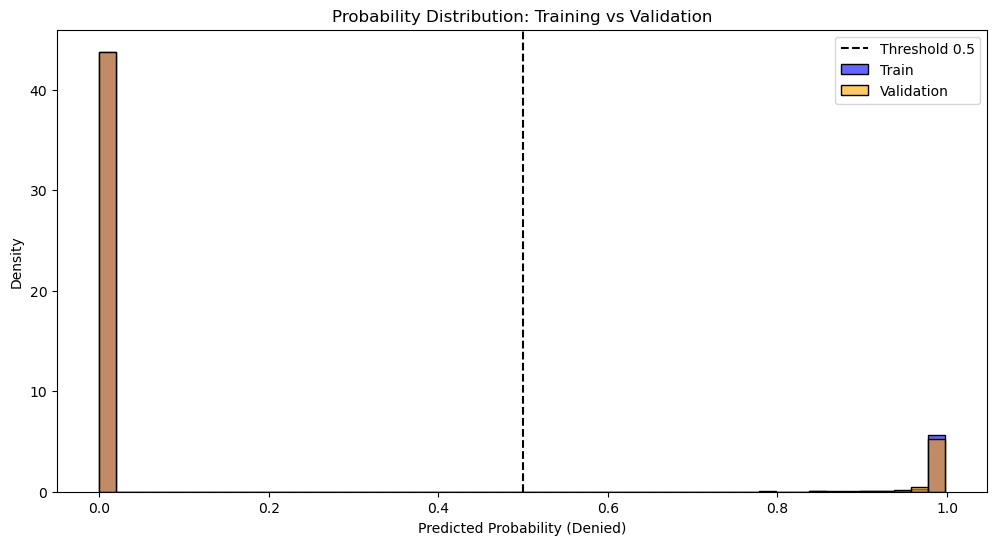

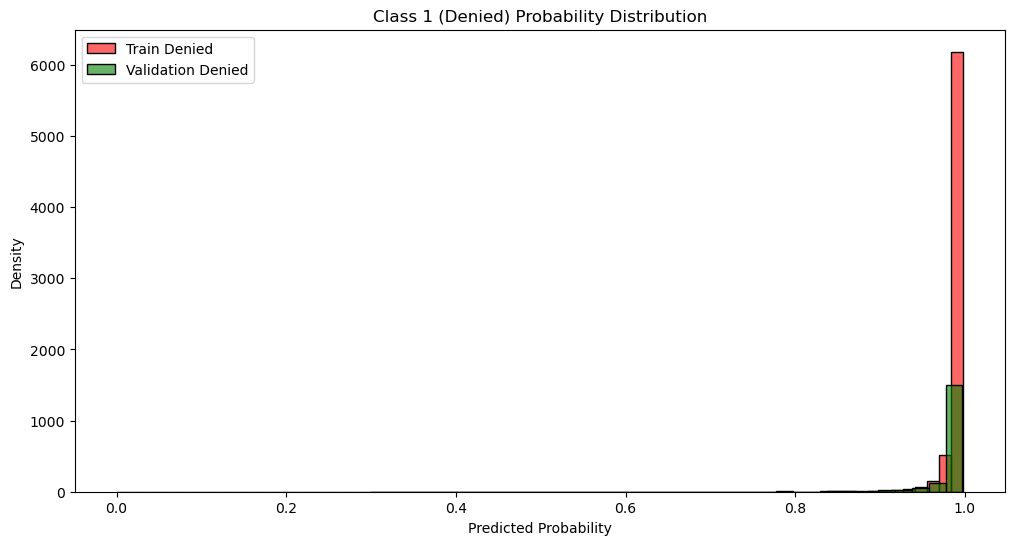

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# -----------------------------
# 1. Predict probabilities
# -----------------------------
# X_train, X_valid, model should already exist (from your pickle load)
y_train_pred_proba = model.predict_proba(X_train)[:,1]  # probability for class 1 (Denied)
y_valid_pred_proba = model.predict_proba(X_valid)[:,1]

# -----------------------------
# 2. Plot distribution of probabilities
# -----------------------------
plt.figure(figsize=(12,6))
sns.histplot(y_train_pred_proba, bins=50, color='blue', label='Train', stat='density', alpha=0.6)
sns.histplot(y_valid_pred_proba, bins=50, color='orange', label='Validation', stat='density', alpha=0.6)
plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold 0.5')
plt.title('Probability Distribution: Training vs Validation')
plt.xlabel('Predicted Probability (Denied)')
plt.ylabel('Density')
plt.legend()
plt.show()

# -----------------------------
# 3. Optional: Compare class-wise distribution
# -----------------------------
plt.figure(figsize=(12,6))
sns.histplot(y_train_pred_proba[y_train==1], bins=50, color='red', label='Train Denied', alpha=0.6)
sns.histplot(y_valid_pred_proba[y_valid==1], bins=50, color='green', label='Validation Denied', alpha=0.6)
plt.title('Class 1 (Denied) Probability Distribution')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend()
plt.show()

In [11]:
print("Train prob mean/std:", np.mean(y_train_pred_proba), np.std(y_train_pred_proba))
print("Valid prob mean/std:", np.mean(y_valid_pred_proba), np.std(y_valid_pred_proba))

Train prob mean/std: 0.12512821551793774 0.32674964076585766
Valid prob mean/std: 0.12490780495577994 0.3262172265035632


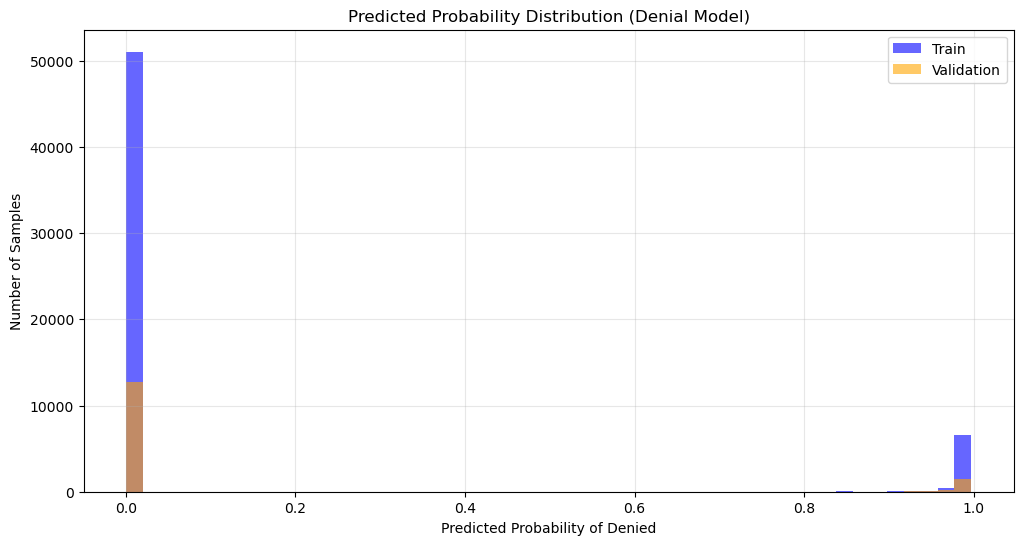

In [12]:
import matplotlib.pyplot as plt

# Assume y_train_pred_proba and y_valid_pred_proba are already defined

plt.figure(figsize=(12,6))

# Train set
plt.hist(y_train_pred_proba, bins=50, alpha=0.6, color='blue', label='Train')

# Validation set
plt.hist(y_valid_pred_proba, bins=50, alpha=0.6, color='orange', label='Validation')

plt.title("Predicted Probability Distribution (Denial Model)")
plt.xlabel("Predicted Probability of Denied")
plt.ylabel("Number of Samples")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [7]:

# ============================================================
# 15. SAVE MODEL BUNDLE
# ============================================================
global_mean = train_df["Target"].mean()
adrg_enc_map = train_df.groupby("ADRG")["ADRG_enc"].mean().to_dict()
pdx_enc_map  = train_df.groupby("PRIM_DX")["PRIM_DX_enc"].mean().to_dict()

model_bundle = {
    "model": model,
    "scaler": scaler,
    "drg_dict": drg_dict,
    "icd_dict": icd_dict,
    "proc_dict": proc_dict,
    "stats_store": stats_store,
    "adrg_enc_map": adrg_enc_map,
    "pdx_enc_map": pdx_enc_map,
    "THRESHOLD": THRESHOLD,
    "global_mean": global_mean,
    "QUERY": QUERY.cpu().numpy()
}

with open("20260330_claim_denial_model.pkl","wb") as f:
    pickle.dump(model_bundle,f)

print("✅ FULL MODEL BUNDLE SAVED SUCCESSFULLY")

✅ FULL MODEL BUNDLE SAVED SUCCESSFULLY


In [13]:
model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.021,
    num_leaves=40,       # slightly lower
    max_depth=5,         # shallower tree
    min_child_samples=100,
    subsample=0.9,
    colsample_bytree=0.7,
    reg_alpha=2.0,
    reg_lambda=5.0,
    scale_pos_weight=4.8,
    random_state=42
)

model.fit(X_train, y_train)

y_pred_prob = model.predict_proba(X_valid)[:,1]
THRESHOLD = 0.428257
y_pred = (y_pred_prob>=THRESHOLD).astype(int)

print(classification_report(y_valid, y_pred))
print("ROC AUC:", roc_auc_score(y_valid, y_pred_prob))

[LightGBM] [Info] Number of positive: 7050, number of negative: 51484
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.740814 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150806
[LightGBM] [Info] Number of data points in the train set: 58534, number of used features: 4628
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.120443 -> initscore=-1.988243
[LightGBM] [Info] Start training from score -1.988243
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


              precision    recall  f1-score   support

           0       1.00      0.99      1.00     12871
           1       0.94      1.00      0.97      1763

    accuracy                           0.99     14634
   macro avg       0.97      1.00      0.98     14634
weighted avg       0.99      0.99      0.99     14634

ROC AUC: 0.9983311425787891


In [14]:
print("Train prob mean/std:", np.mean(y_train_pred_proba), np.std(y_train_pred_proba))
print("Valid prob mean/std:", np.mean(y_valid_pred_proba), np.std(y_valid_pred_proba))

Train prob mean/std: 0.12512821551793774 0.32674964076585766
Valid prob mean/std: 0.12490780495577994 0.3262172265035632


In [8]:
# ============================================================
# 🔥 PREDICTION PIPELINE USING SAVED PICKLE MODEL
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

# -------------------------
# 1️⃣ LOAD SAVED MODEL BUNDLE
# -------------------------
with open("20260330_claim_denial_model.pkl", "rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
scaler = bundle["scaler"]
drg_dict = bundle["drg_dict"]
icd_dict = bundle["icd_dict"]
proc_dict = bundle["proc_dict"]
adrg_enc_map = bundle["adrg_enc_map"]
pdx_enc_map = bundle["pdx_enc_map"]
THRESHOLD = bundle["THRESHOLD"]
EMB_DIM = 768
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
QUERY = torch.tensor(bundle["QUERY"], device=DEVICE, dtype=torch.float32)

# -------------------------
# 2️⃣ FUNCTIONS TO MAP EMBEDDINGS
# -------------------------
def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str=="":
        return []
    codes = code_str.split(",")
    return [np.array(icd_dict[c], dtype=np.float32) for c in codes if c in icd_dict and len(icd_dict[c])==EMB_DIM]

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str=="":
        return []
    codes = code_str.split(",")
    return [np.array(proc_dict[c], dtype=np.float32) for c in codes if c in proc_dict and len(proc_dict[c])==EMB_DIM]

def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []
    for lst in col:
        if not isinstance(lst,list) or len(lst)==0:
            pooled.append(zero_vec)
            continue
        lst = [x for x in lst if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)]
        if len(lst)==0:
            pooled.append(zero_vec)
            continue
        if len(lst)==1:
            pooled.append(lst[0])
            continue
        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()
        pooled.append(vec.astype(np.float32))
    return pd.Series(pooled, index=col.index)

# -------------------------
# 3️⃣ BUILD FEATURE MATRIX FOR UNSEEN DATA
# -------------------------
def build_X_unseen(df):
    # Numeric
    num_cols = ["Payments","LOS","Age"]
    df[num_cols] = scaler.transform(df[num_cols])
    numeric = df[num_cols].values.astype(np.float32)
    
    # Encoding
    df["ADRG_enc"] = df["ADRG"].map(adrg_enc_map).fillna(np.mean(list(adrg_enc_map.values())))
    df["PRIM_DX_enc"] = df["PRIM_DX"].map(pdx_enc_map).fillna(np.mean(list(pdx_enc_map.values())))
    enc = df[["ADRG_enc","PRIM_DX_enc"]].values.astype(np.float32)
    
    # Counts
    counts = df[["A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"]].values.astype(np.float32)
    
    # Embeddings
    def safe_stack(series):
        return np.stack(series.apply(lambda x: x if isinstance(x,np.ndarray) and x.shape==(EMB_DIM,)
                                     else np.zeros(EMB_DIM,dtype=np.float32)))
    
    drg = safe_stack(df["DRG_EMB"])
    pdx = safe_stack(df["PRIM_DX_EMB"])
    mcc = safe_stack(df["MCC_EMB_POOLED"])
    cc  = safe_stack(df["CC_EMB_POOLED"])
    gen = safe_stack(df["GENERAL_EMB_POOLED"])
    proc= safe_stack(df["PROC_EMB_POOLED"])
    
    emb = np.concatenate([drg, pdx, mcc, cc, gen, proc], axis=1)
    
    X = np.concatenate([emb, counts, numeric, enc], axis=1)
    return X

# -------------------------
# 4️⃣ PREDICTION FUNCTION
# -------------------------
def predict_claims(df_raw, output_file="predictions.xlsx"):
    df = df_raw.copy()
    
    # Map embeddings
    df["DRG_EMB"] = df["ADRG"].map(drg_dict)
    df["PRIM_DX_EMB"] = df["PRIM_DX"].map(icd_dict)
    df["MCC_EMB_LIST"] = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
    df["CC_EMB_LIST"]  = df["A_DX_CC_Set"].apply(map_icd_embeddings)
    df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)
    df["PROC_EMB_LIST"] = df["A_PX_List"].apply(map_proc_embeddings)
    
    # Attention pooling
    df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
    df["CC_EMB_POOLED"]  = attention_pooling(df["CC_EMB_LIST"])
    df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
    df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])
    
    # Build features
    X = build_X_unseen(df)
    
    # Predict
    probs = model.predict_proba(X)[:,1]
    df["DENIED_PROB"] = probs
    df["DENIED_FLAG"] = (probs >= THRESHOLD).astype(int)
    
    # Save
    df.to_excel(output_file, index=False)
    print(f"✅ Predictions saved to {output_file}")
    return df



In [ ]:
# ============================================================
# Example usage:
# df_unseen = pd.read_excel("unseen_claims.xlsx")
# df_pred = predict_claims(df_unseen, "unseen_predictions.xlsx")

# prev

In [19]:
# ============================================================
# 🔥 FULL CLAIM DENIAL PIPELINE (FINAL - CLEAN & STABLE)
# ============================================================

import pandas as pd
import numpy as np
import torch
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, roc_auc_score

# -------------------------
# CONFIG
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EMB_DIM = 768
QUERY = torch.randn(EMB_DIM, device=DEVICE)

# ============================================================
# 1. LOAD DATA
# ============================================================

df = df_hum_ms_drg.copy()
df = df.rename(columns={'AGE':'Age'})

# ============================================================
# 2. CREATE DX / PX LISTS
# ============================================================

adx_cols = [f"A_DX{i}" for i in range(2,26)]
apx_cols = [f"A_PX{i}" for i in range(1,26)]

df["A_DX_List"] = df[adx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["A_PX_List"] = df[apx_cols].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

adx_cols_b = [f"B_DX{i}" for i in range(2,26)]
apx_cols_b = [f"B_PX{i}" for i in range(1,26)]

df["B_DX_List"] = df[adx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)
df["B_PX_List"] = df[apx_cols_b].apply(lambda x: ",".join(sorted([str(i) for i in x if pd.notna(i)])), axis=1)

# ============================================================
# 3. SPLIT DX TYPES
# ============================================================

def split_dx_types(dx_string):
    if pd.isna(dx_string) or dx_string=="":
        return pd.Series(["","","",0,0,0])

    dx_list = [x.strip() for x in dx_string.split(",")]

    mcc = [x.split(" - ")[0] for x in dx_list if "- MCC" in x]
    cc  = [x.split(" - ")[0] for x in dx_list if "- CC" in x]
    gen = [x.split(" - ")[0] for x in dx_list if "- MCC" not in x and "- CC" not in x]

    return pd.Series([
        ",".join(sorted(mcc)),
        ",".join(sorted(cc)),
        ",".join(sorted(gen)),
        len(mcc), len(cc), len(gen)
    ])

# A-side
df[[
    "A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set",
    "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"
]] = df["A_DX_List"].apply(split_dx_types)

# B-side
df[[
    "B_DX_MCC_Set","B_DX_CC_Set","B_DX_General_Set",
    "B_DX_MCC_Count","B_DX_CC_Count","B_DX_General_Count"
]] = df["B_DX_List"].apply(split_dx_types)

# ============================================================
# 4. CLEAN DATA
# ============================================================

df = df[~(df['A_DX_List'].notna() & (df['A_DX_List'].str.len() == 0))]
df = df[~(df['B_DX_List'].notna() & (df['B_DX_List'].str.len() == 0))]
df = df.dropna(subset=['B_DRG','B_PRIMDX'])

# ============================================================
# 5. B-PART FLAGS (FULL LOGIC)
# ============================================================

df["B_PRIMDX_CLEAN"] = df["B_PRIMDX"].str.replace(r"\s*-\s*(MCC|CC)","",regex=True).str.strip().str.upper()

def get_pdx_flag(row):
    a_prim = str(row["PRIM_DX"]).strip()
    b_prim = str(row["B_PRIMDX_CLEAN"]).strip()

    A_set = set(filter(None,[row["A_DX_MCC_Set"],row["A_DX_CC_Set"],row["A_DX_General_Set"]]))
    B_set = set(filter(None,[row["B_DX_MCC_Set"],row["B_DX_CC_Set"],row["B_DX_General_Set"]]))

    if a_prim==b_prim: return "SAME"
    if (b_prim in A_set) and (a_prim in B_set): return "RESEQUENCE"
    if a_prim not in B_set:
        if b_prim in A_set: return "PDX_DOWNGRADE"
        else: return "A_PRIMDX_REMOVED"
    return "B_PDX_Added"

df["PDX_FLAG"] = df.apply(get_pdx_flag,axis=1)

def check_px_removed(row):
    A_set = set(filter(None, row["A_PX_List"].split(",")))
    B_set = set(filter(None, row["B_PX_List"].split(",")))

    if A_set == B_set:
        return pd.Series(["SAME",""])

    removed = A_set - B_set
    return pd.Series(["REMOVED", ",".join(sorted(removed)) if removed else ""])

df[["PX_FLAG","PX_REMOVED"]] = df.apply(check_px_removed,axis=1)

df["DRG_FLAG"] = np.where(df["ADRG"]==df["B_DRG"], "SAME","DIFFERENT")

# ============================================================
# 6. LOAD EMBEDDINGS
# ============================================================

with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    data = pickle.load(f)

drg_dict, icd_dict, proc_dict = data["drg_dict"], data["icd_dict"], data["proc_dict"]   

df["DRG_EMB"] = df["ADRG"].map(drg_dict)

def map_icd_embeddings(code_str):
    if pd.isna(code_str) or code_str == "":
        return []

    codes = code_str.split(",")

    emb_list = []
    for c in codes:
        c = c.strip()
        emb = icd_dict.get(c)

        if emb is not None and len(emb) == EMB_DIM:
            emb_list.append(np.array(emb, dtype=np.float32))

    return emb_list

def map_proc_embeddings(code_str):
    if pd.isna(code_str) or code_str == "":
        return []

    codes = code_str.split(",")

    emb_list = []
    for c in codes:
        c = c.strip()
        emb = proc_dict.get(c)   # ✅ USE PROC DICT

        if emb is not None and len(emb) == EMB_DIM:
            emb_list.append(np.array(emb, dtype=np.float32))

    return emb_list

# Diagnosis-based embeddings
df["PRIM_DX_EMB"] = df["PRIM_DX"].map(icd_dict)

df["MCC_EMB_LIST"]     = df["A_DX_MCC_Set"].apply(map_icd_embeddings)
df["CC_EMB_LIST"]      = df["A_DX_CC_Set"].apply(map_icd_embeddings)
df["GENERAL_EMB_LIST"] = df["A_DX_General_Set"].apply(map_icd_embeddings)

# Procedure embeddings
df["PROC_EMB_LIST"]    = df["A_PX_List"].apply(map_proc_embeddings)

df = df[~df["DRG_EMB"].isnull()]

# ============================================================
# 7. ATTENTION POOLING (SAFE)
# ============================================================

def attention_pooling(col):
    zero_vec = np.zeros(EMB_DIM, dtype=np.float32)
    pooled = []

    for lst in col:

        if not isinstance(lst, list) or len(lst) == 0:
            pooled.append(zero_vec)
            continue

        lst = [x for x in lst if isinstance(x, np.ndarray) and x.shape == (EMB_DIM,)]

        if len(lst) == 0:
            pooled.append(zero_vec)
            continue

        if len(lst) == 1:
            pooled.append(lst[0])
            continue

        X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
        attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
        vec = (attn @ X).squeeze(0).cpu().numpy()

        if vec.shape != (EMB_DIM,):
            pooled.append(zero_vec)
        else:
            pooled.append(vec.astype(np.float32))

    return pd.Series(pooled, index=col.index)

df["MCC_EMB_POOLED"] = attention_pooling(df["MCC_EMB_LIST"])
df["CC_EMB_POOLED"] = attention_pooling(df["CC_EMB_LIST"])
df["GENERAL_EMB_POOLED"] = attention_pooling(df["GENERAL_EMB_LIST"])
df["PROC_EMB_POOLED"] = attention_pooling(df["PROC_EMB_LIST"])
# ============================================================
# 8. TRAIN / VALID SPLIT
# ============================================================

train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["Target"]
)

# ============================================================
# 9. SCALING
# ============================================================

num_cols = ["Payments","LOS","Age"]

scaler = StandardScaler()
train_df.loc[:, num_cols] = scaler.fit_transform(train_df[num_cols])
valid_df.loc[:, num_cols] = scaler.transform(valid_df[num_cols])

# ============================================================
# 10. TARGET ENCODING (FIXED)
# ============================================================

def target_encode(train, valid, col, alpha=20):

    mean = train["Target"].mean()
    stats = train.groupby(col)["Target"].agg(["mean","count"])

    smooth = (stats["mean"]*stats["count"] + mean*alpha)/(stats["count"]+alpha)

    train[col+"_enc"] = train[col].map(smooth)
    valid[col+"_enc"] = valid[col].map(smooth)

    valid[col+"_enc"] = valid[col+"_enc"].fillna(mean)

    return train, valid

train_df, valid_df = target_encode(train_df, valid_df, "ADRG")
train_df, valid_df = target_encode(train_df, valid_df, "PRIM_DX")

# ============================================================
# 11. CODE STATS
# ============================================================

def create_stats(train, col):
    temp = train[[col,"Target"]].dropna()
    temp[col] = temp[col].str.split(",")
    temp = temp.explode(col)
    temp[col] = temp[col].str.strip()

    stats = temp.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

def apply_stats(df, stats, col, prefix):

    def calc(x):
        if pd.isna(x):
            return [0,0]

        vals = [stats.loc[c.strip()] for c in str(x).split(",") if c.strip() in stats.index]

        if not vals:
            return [0,0]

        rates = [v["rate"] for v in vals]
        freqs = [v["freq"] for v in vals]

        return [np.mean(rates), np.mean(freqs)]

    tmp = df[col].apply(calc)

    df[prefix+"_rate"] = tmp.apply(lambda x: x[0])
    df[prefix+"_freq"] = tmp.apply(lambda x: x[1])

    return df

cols = ["A_DX_MCC_Set","A_DX_CC_Set","A_DX_General_Set","A_PX_List"]
prefix = ["MCC","CC","GEN","PX"]

stats_store = {}

for c in cols:
    stats_store[c] = create_stats(train_df, c)

for c,p in zip(cols,prefix):
    train_df = apply_stats(train_df, stats_store[c], c, p)
    valid_df = apply_stats(valid_df, stats_store[c], c, p)

# ============================================================
# 12. B-PART STATS
# ============================================================

def create_flag_stats(train, col):
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = [f"{col}_rate", f"{col}_freq"]
    return stats

def apply_flag(df, stats, col):
    mean = df["Target"].mean()

    df[f"{col}_rate"] = df[col].map(stats[f"{col}_rate"])
    df[f"{col}_freq"] = df[col].map(stats[f"{col}_freq"])

    df[f"{col}_rate"] = df[f"{col}_rate"].fillna(mean)
    df[f"{col}_freq"] = df[f"{col}_freq"].fillna(0)

    return df

for col in ["PDX_FLAG","PX_FLAG","DRG_FLAG"]:
    stats = create_flag_stats(train_df, col)
    train_df = apply_flag(train_df, stats, col)
    valid_df = apply_flag(valid_df, stats, col)

# ============================================================
# 13. BUILD FEATURES (SAFE)
# ============================================================

def safe_stack(series):
    return np.stack(series.apply(
        lambda x: x if isinstance(x, np.ndarray) and x.shape==(EMB_DIM,) 
        else np.zeros(EMB_DIM, dtype=np.float32)
    ))

def build_X(df):
    drg = safe_stack(df["DRG_EMB"])
    pdx = safe_stack(df["PRIM_DX_EMB"])
    mcc = safe_stack(df["MCC_EMB_POOLED"])
    cc  = safe_stack(df["CC_EMB_POOLED"])
    gen = safe_stack(df["GENERAL_EMB_POOLED"])
    proc = safe_stack(df["PROC_EMB_POOLED"])

    emb = np.concatenate([drg,pdx,mcc, cc, gen,proc], axis=1)

    counts = df[[
        "A_DX_MCC_Count","A_DX_CC_Count","A_DX_General_Count"
    ]].values

    numeric = df[["Payments","LOS","Age"]].values

    stats = df[[
        "ADRG_enc","PRIM_DX_enc",
        "MCC_rate","MCC_freq",
        "CC_rate","CC_freq",
        "GEN_rate","GEN_freq",
        "PX_rate","PX_freq"
    ]].values

    bstats = df[[
        "PDX_FLAG_rate","PDX_FLAG_freq",
        "PX_FLAG_rate","PX_FLAG_freq",
        "DRG_FLAG_rate","DRG_FLAG_freq"
    ]].values

    return np.concatenate([emb, counts, numeric, stats, bstats], axis=1)

X_train = build_X(train_df)
X_valid = build_X(valid_df)

y_train = train_df["Target"].values
y_valid = valid_df["Target"].values


C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_11448\470855442.py:234: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.59229804 -0.43234972 -0.75224636 ... -0.2724014   0.52734021
  1.64697845]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:, num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_11448\470855442.py:234: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.93020726  0.34867456 -3.05744556 ... -1.56207575 -0.06670594
  0.51482676]' has dtype incompatible with Int32, please explicitly cast to a compatible dtype first.
  train_df.loc[:, num_cols] = scaler.fit_transform(train_df[num_cols])
C:\Users\arunkumara\AppData\Local\Temp\1\ipykernel_11448\470855442.py:235: FutureWarning: Setting an item of incompatible dtype is depreca

In [20]:
model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.02126904140506236,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.9545822444135974,
    colsample_bytree=0.6615288127260239,
    reg_alpha=1.306597950617057,
    reg_lambda=4.579866204146278,
    scale_pos_weight=4.8305186183209345,
    random_state=42
)

model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 7019, number of negative: 50814
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.720691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1150503
[LightGBM] [Info] Number of data points in the train set: 57833, number of used features: 4630
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121367 -> initscore=-1.979551
[LightGBM] [Info] Start training from score -1.979551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive

LGBMClassifier(colsample_bytree=0.6615288127260239,
               learning_rate=0.02126904140506236, max_depth=6,
               min_child_samples=64, n_estimators=308, num_leaves=48,
               random_state=42, reg_alpha=1.306597950617057,
               reg_lambda=4.579866204146278,
               scale_pos_weight=4.8305186183209345,
               subsample=0.9545822444135974)

In [21]:
THRESHOLD = 0.4282574824046108

probs = model.predict_proba(X_valid)[:, 1]
preds = (probs >= THRESHOLD).astype(int)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [23]:
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print("Confusion Matrix:")
print(confusion_matrix(y_valid, preds))

print("\nClassification Report:")
print(classification_report(y_valid, preds))

print("\nROC-AUC:", roc_auc_score(y_valid, probs))

Confusion Matrix:
[[12614    90]
 [    3  1752]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     12704
           1       0.95      1.00      0.97      1755

    accuracy                           0.99     14459
   macro avg       0.98      1.00      0.99     14459
weighted avg       0.99      0.99      0.99     14459


ROC-AUC: 0.9987351719089754


In [24]:
# ============================================================
# 🔥 SAVE FULL MODEL BUNDLE (PRODUCTION READY)
# ============================================================

# ---- Global means (for unseen handling) ----
global_mean = train_df["Target"].mean()

# ---- Save target encoding maps ----
adrg_enc_map = train_df.groupby("ADRG")["ADRG_enc"].mean().to_dict()
pdx_enc_map  = train_df.groupby("PRIM_DX")["PRIM_DX_enc"].mean().to_dict()

# ---- Save B-part stats ----
def extract_flag_stats(train, col):
    stats = train.groupby(col)["Target"].agg(["mean","count"])
    stats.columns = ["rate","freq"]
    return stats

pdx_flag_stats = extract_flag_stats(train_df, "PDX_FLAG")
px_flag_stats  = extract_flag_stats(train_df, "PX_FLAG")
drg_flag_stats = extract_flag_stats(train_df, "DRG_FLAG")

# ---- SAVE EVERYTHING ----
model_bundle = {
    "model": model,
    "scaler": scaler,
    
    # embeddings
    "drg_dict": drg_dict,
    "icd_dict": icd_dict,
    "proc_dict":proc_dict,
    
    # stats
    "stats_store": stats_store,
    
    # encoding
    "adrg_enc_map": adrg_enc_map,
    "pdx_enc_map": pdx_enc_map,
    
    # B-part stats (for knowledge)
    "pdx_flag_stats": pdx_flag_stats,
    "px_flag_stats": px_flag_stats,
    "drg_flag_stats": drg_flag_stats,
    
    # config
    "QUERY": QUERY.cpu().numpy(),
    "THRESHOLD": THRESHOLD,
    "global_mean": global_mean
}

# ---- SAVE FILE ----
with open("20260330_claim_denial_model.pkl", "wb") as f:
    pickle.dump(model_bundle, f)

print("✅ FULL MODEL BUNDLE SAVED SUCCESSFULLY")

✅ FULL MODEL BUNDLE SAVED SUCCESSFULLY


In [ ]:
import numpy as np
import pandas as pd
import torch
import pickle

EMB_DIM = 768
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ============================================================
# LOAD MODEL
# ============================================================

with open("final_model_bundle.pkl","rb") as f:
    bundle = pickle.load(f)

model = bundle["model"]
scaler = bundle["scaler"]
stats_store = bundle["stats_store"]
QUERY = torch.tensor(bundle["QUERY"], device=DEVICE)
THRESHOLD = bundle["THRESHOLD"]

# load embeddings
with open(r"C:\Arun_MIX\Model\20260326_embeddings.pkl","rb") as f:
    emb_data = pickle.load(f)

drg_dict = emb_data["drg_dict"]
icd_dict = emb_data["icd_dict"]

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def map_embeddings(code_str):
    if not code_str:
        return []
    return [
        np.array(icd_dict[c.strip()], dtype=np.float32)
        for c in code_str.split(",")
        if c.strip() in icd_dict
    ]

def attention_pool(lst):
    zero = np.zeros(EMB_DIM, dtype=np.float32)

    if not lst:
        return zero

    lst = [x for x in lst if isinstance(x, np.ndarray) and x.shape==(EMB_DIM,)]

    if len(lst) == 0:
        return zero

    if len(lst) == 1:
        return lst[0]

    X = torch.tensor(np.stack(lst), dtype=torch.float32, device=DEVICE)
    attn = torch.softmax((QUERY.unsqueeze(0) @ X.T)/np.sqrt(EMB_DIM), dim=-1)
    return (attn @ X).squeeze(0).cpu().numpy()

def compute_stats(code_str, stats):
    if not code_str:
        return [0,0]

    vals = []
    for c in code_str.split(","):
        c = c.strip()
        if c in stats.index:
            vals.append(stats.loc[c])

    if not vals:
        return [0,0]

    return [
        np.mean([v["rate"] for v in vals]),
        np.mean([v["freq"] for v in vals])
    ]

# ============================================================
# MAIN PREDICT FUNCTION
# ============================================================

def predict_claim(input_dict):

    df = pd.DataFrame([input_dict])

    # -------------------------
    # SCALE NUMERIC
    # -------------------------
    df[["Payments","LOS","Age"]] = scaler.transform(df[["Payments","LOS","Age"]])

    # -------------------------
    # EMBEDDINGS
    # -------------------------
    mcc_vec = attention_pool(map_embeddings(df.loc[0,"MCC_Set"]))
    cc_vec  = attention_pool(map_embeddings(df.loc[0,"CC_Set"]))
    gen_vec = attention_pool(map_embeddings(df.loc[0,"GEN_Set"]))

    emb = np.concatenate([mcc_vec, cc_vec, gen_vec])

    # -------------------------
    # COUNTS
    # -------------------------
    counts = np.array([
        len(df.loc[0,"MCC_Set"].split(",")) if df.loc[0,"MCC_Set"] else 0,
        len(df.loc[0,"CC_Set"].split(",")) if df.loc[0,"CC_Set"] else 0,
        len(df.loc[0,"GEN_Set"].split(",")) if df.loc[0,"GEN_Set"] else 0
    ])

    # -------------------------
    # TARGET ENCODING (approx via stats)
    # -------------------------
    adrg_enc = stats_store["A_DX_MCC_Set"]["rate"].mean()
    pdx_enc  = stats_store["A_DX_MCC_Set"]["rate"].mean()

    # -------------------------
    # CODE STATS
    # -------------------------
    mcc_stats = compute_stats(df.loc[0,"MCC_Set"], stats_store["A_DX_MCC_Set"])
    cc_stats  = compute_stats(df.loc[0,"CC_Set"], stats_store["A_DX_CC_Set"])
    gen_stats = compute_stats(df.loc[0,"GEN_Set"], stats_store["A_DX_General_Set"])
    px_stats  = compute_stats(df.loc[0,"PX_Set"], stats_store["A_PX_List"])

    stats_vec = np.array([
        adrg_enc, pdx_enc,
        *mcc_stats, *cc_stats, *gen_stats, *px_stats
    ])

    # -------------------------
    # B-PART DEFAULT (NEUTRAL)
    # -------------------------
    bstats = np.array([0.5,0, 0.5,0, 0.5,0])

    # -------------------------
    # FINAL VECTOR
    # -------------------------
    numeric = df[["Payments","LOS","Age"]].values[0]

    X = np.concatenate([emb, counts, numeric, stats_vec, bstats]).reshape(1,-1)

    # -------------------------
    # PREDICTION
    # -------------------------
    prob = model.predict_proba(X)[0,1]
    pred = int(prob >= THRESHOLD)

    return {
        "denial_probability": float(prob),
        "prediction": "DENIED" if pred==1 else "APPROVED"
    }

[LightGBM] [Info] Number of positive: 7019, number of negative: 50814
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.408691 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 590450
[LightGBM] [Info] Number of data points in the train set: 57833, number of used features: 2326
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.121367 -> initscore=-1.979551
[LightGBM] [Info] Start training from score -1.979551
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


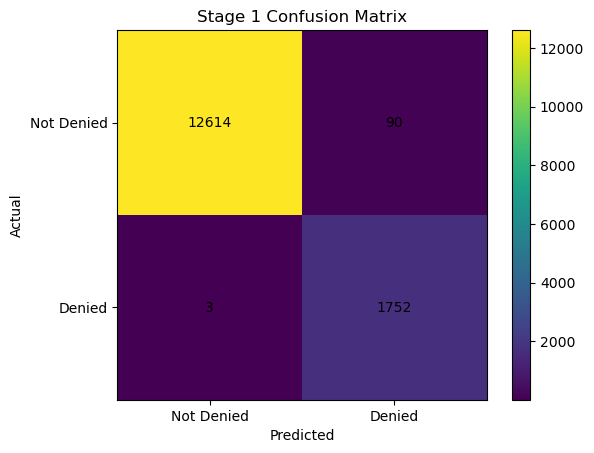

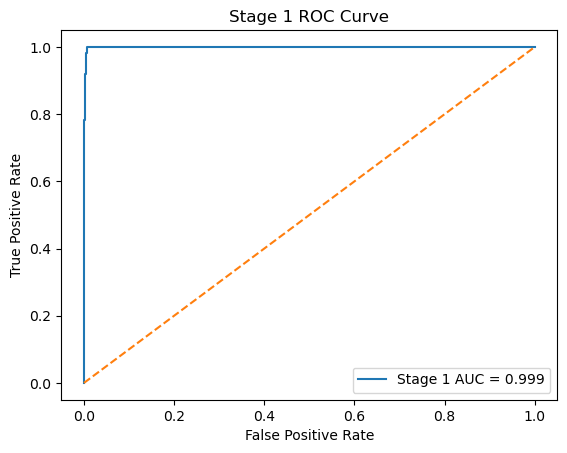

[LightGBM] [Info] Number of positive: 1752, number of negative: 90
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.096297 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 589675
[LightGBM] [Info] Number of data points in the train set: 1842, number of used features: 2323
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.951140 -> initscore=2.968704
[LightGBM] [Info] Start training from score 2.968704
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


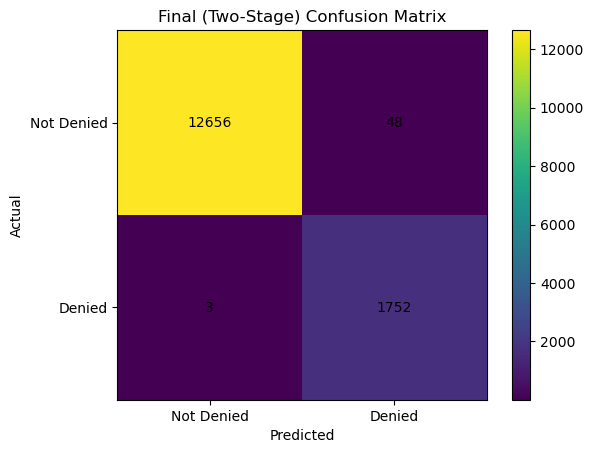

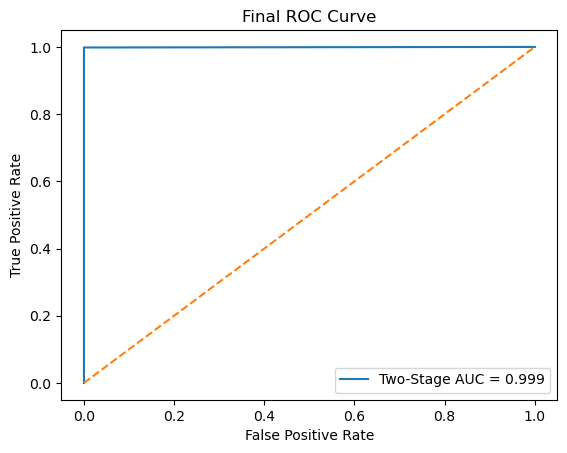

Stage 1 Passed Cases: 1842

FINAL RESULTS:
[[12656    48]
 [    3  1752]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     12704
           1       0.97      1.00      0.99      1755

    accuracy                           1.00     14459
   macro avg       0.99      1.00      0.99     14459
weighted avg       1.00      1.00      1.00     14459

ROC-AUC: 0.9991391992651438


In [10]:
# ============================================================
# 🔥 FULL TWO-STAGE PIPELINE + VISUALIZATION (SINGLE CELL)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# ============================================================
# 🔥 STAGE 1 MODEL (OPTUNA PARAMS - HIGH RECALL)
# ============================================================

stage1_model = LGBMClassifier(
    n_estimators=308,
    learning_rate=0.02126904140506236,
    num_leaves=48,
    max_depth=6,
    min_child_samples=64,
    subsample=0.9545822444135974,
    colsample_bytree=0.6615288127260239,
    reg_alpha=1.306597950617057,
    reg_lambda=4.579866204146278,
    scale_pos_weight=4.8305186183209345,
    random_state=42,
    n_jobs=-1
)

stage1_model.fit(X_train, y_train)

# Stage 1 predictions
probs_stage1 = stage1_model.predict_proba(X_valid)[:, 1]
stage1_threshold = 0.4282574824046108
stage1_preds = (probs_stage1 > stage1_threshold).astype(int)
stage1_mask = stage1_preds.astype(bool)

# ============================================================
# 📊 STAGE 1 CONFUSION MATRIX
# ============================================================

cm1 = confusion_matrix(y_valid, stage1_preds)

plt.figure()
plt.imshow(cm1)
plt.title("Stage 1 Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])

for i in range(cm1.shape[0]):
    for j in range(cm1.shape[1]):
        plt.text(j, i, cm1[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 STAGE 1 ROC CURVE
# ============================================================

fpr1, tpr1, _ = roc_curve(y_valid, probs_stage1)
auc1 = roc_auc_score(y_valid, probs_stage1)

plt.figure()
plt.plot(fpr1, tpr1, label=f"Stage 1 AUC = {auc1:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Stage 1 ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 🔥 PREPARE STAGE 2 DATA
# ============================================================

X_stage2 = X_valid[stage1_mask].copy()
y_stage2 = y_valid[stage1_mask]

X_stage2 = np.hstack([
    X_stage2,
    probs_stage1[stage1_mask].reshape(-1,1)
])

# ============================================================
# 🔥 STAGE 2 MODEL (BALANCED OPTUNA PARAMS)
# ============================================================

stage2_model = LGBMClassifier(
    n_estimators=348,
    learning_rate=0.018321074923569082,
    num_leaves=32,
    max_depth=6,
    min_child_samples=91,
    subsample=0.976533671330113,
    colsample_bytree=0.6861578285305313,
    reg_alpha=1.2161768866427825,
    reg_lambda=3.698341838082158,
    scale_pos_weight=2.9316719462212024,
    random_state=42,
    n_jobs=-1
)

stage2_model.fit(X_stage2, y_stage2)

# ============================================================
# 🔥 FINAL PREDICTIONS (TWO-STAGE)
# ============================================================

final_preds = np.zeros(len(X_valid))
final_probs = np.zeros(len(X_valid))

X_stage2_full = X_valid[stage1_mask].copy()
X_stage2_full = np.hstack([
    X_stage2_full,
    probs_stage1[stage1_mask].reshape(-1,1)
])

probs_stage2 = stage2_model.predict_proba(X_stage2_full)[:, 1]

stage2_threshold = 0.5058609937194245
stage2_preds = (probs_stage2 > stage2_threshold).astype(int)

final_preds[stage1_mask] = stage2_preds
final_probs[stage1_mask] = probs_stage2

# ============================================================
# 📊 FINAL CONFUSION MATRIX
# ============================================================

cm2 = confusion_matrix(y_valid, final_preds)

plt.figure()
plt.imshow(cm2)
plt.title("Final (Two-Stage) Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0,1], ["Not Denied","Denied"])
plt.yticks([0,1], ["Not Denied","Denied"])

for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        plt.text(j, i, cm2[i,j], ha="center", va="center")

plt.show()

# ============================================================
# 📈 FINAL ROC CURVE
# ============================================================

fpr2, tpr2, _ = roc_curve(y_valid, final_probs)
auc2 = roc_auc_score(y_valid, final_probs)

plt.figure()
plt.plot(fpr2, tpr2, label=f"Two-Stage AUC = {auc2:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Final ROC Curve")
plt.legend()
plt.show()

# ============================================================
# 📊 FINAL METRICS
# ============================================================

print("Stage 1 Passed Cases:", stage1_mask.sum())

print("\nFINAL RESULTS:")
print(confusion_matrix(y_valid, final_preds))
print(classification_report(y_valid, final_preds))
print("ROC-AUC:", auc2)